# Modelo Proyecto 2 

#### Importo las librerías necesarias 

In [28]:
import numpy as np
import pandas as pd
import tensorflow as tf
import mlflow.tensorflow
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


#### Importo los datos 

In [29]:
df = pd.read_csv("Clean_data.csv")

print(df.head)
print(df.shape)

<bound method NDFrame.head of        periodo estu_tipodocumento  estu_consecutivo cole_area_ubicacion  \
0        20181                 CC  SB11201810003214              URBANO   
1        20181                 CC  SB11201810003214              URBANO   
2        20181                 TI  SB11201810043861               RURAL   
3        20181                 TI  SB11201810043861               RURAL   
4        20181                 CC  SB11201810004937               RURAL   
...        ...                ...               ...                 ...   
32338    20181                 TI  SB11201810001140              URBANO   
32339    20181                 TI  SB11201810024724              URBANO   
32340    20181                 TI  SB11201810024724              URBANO   
32341    20181                 TI  SB11201810019065              URBANO   
32342    20181                 TI  SB11201810019065              URBANO   

      cole_bilingue cole_calendario cole_caracter  \
0               

#### Identifico los NAs en los datos  y revisamos el tipo de datos

In [30]:
df.isna().sum()
df.dropna(inplace=True)
df.dtypes

periodo                            int64
estu_tipodocumento                object
estu_consecutivo                  object
cole_area_ubicacion               object
cole_bilingue                     object
cole_calendario                   object
cole_caracter                     object
cole_cod_dane_establecimiento      int64
cole_cod_dane_sede                 int64
cole_cod_depto_ubicacion           int64
cole_cod_mcpio_ubicacion           int64
cole_codigo_icfes                  int64
cole_depto_ubicacion              object
cole_genero                       object
cole_jornada                      object
cole_mcpio_ubicacion              object
cole_naturaleza                   object
cole_nombre_establecimiento       object
cole_nombre_sede                  object
cole_sede_principal               object
estu_cod_depto_presentacion      float64
estu_cod_mcpio_presentacion      float64
estu_cod_reside_depto            float64
estu_cod_reside_mcpio            float64
estu_depto_prese

### Definimos listas para las variables categóricas enteras, categóricas string y numéricas.

In [31]:
categoricas_enteras = [
    'periodo','cole_cod_dane_establecimiento','cole_cod_dane_sede','cole_cod_depto_ubicacion','cole_cod_mcpio_ubicacion','cole_codigo_icfes',
    'punt_sociales_ciudadanas','punt_c_naturales','punt_lectura_critica','punt_global','semestre_prueba'
]

numericas_flotantes = ['estu_cod_depto_presentacion','estu_cod_mcpio_presentacion','estu_cod_reside_depto','estu_cod_reside_mcpio',
    'punt_ingles','punt_matematicas'
]

categoricas_string = ['estu_tipodocumento','estu_consecutivo','cole_area_ubicacion','cole_bilingue','cole_calendario','cole_caracter',
    'cole_depto_ubicacion','cole_genero','cole_jornada','cole_mcpio_ubicacion','cole_naturaleza','cole_nombre_establecimiento',
    'cole_nombre_sede','cole_sede_principal','estu_depto_presentacion','estu_depto_reside','estu_estadoinvestigacion','estu_estudiante',
    'estu_fechanacimiento','estu_genero','estu_mcpio_presentacion','estu_mcpio_reside','estu_nacionalidad','estu_pais_reside','estu_privado_libertad',
    'fami_cuartoshogar','fami_educacionmadre','fami_educacionpadre','fami_estratovivienda','fami_personashogar','fami_tieneautomovil','fami_tienecomputador',
    'fami_tieneinternet','fami_tienelavadora','desemp_ingles'
]

#Seleccionar solo las variables socio demograficas y de entorno educativo 

variables_sociodemograficas = [
    'cole_area_ubicacion', 'cole_bilingue', 'cole_calendario', 'cole_caracter',
    'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_depto_ubicacion', 'cole_mcpio_ubicacion',
    'estu_tipodocumento', 'estu_genero', 'estu_depto_reside', 'estu_mcpio_reside',
    'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad',
    'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda',
    'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora'
]

### Calculo el promedio nacional del promedio global

In [32]:
promedio_nacional = df['punt_global'].mean()
print(f"Promedio nacional de puntaje global: {promedio_nacional:.2f}")

Promedio nacional de puntaje global: 300.21


#### Creo columna de desempeño (0 =Bajo, 1 = Medio, 2 = Alto)

In [33]:
def clasificar_desempeno(puntaje):
    if puntaje < promedio_nacional * 0.9:
        return 0  # bajo
    elif puntaje < promedio_nacional * 1.1:
        return 1  # medio
    else:
        return 2  # alto

df['desempeno'] = df['punt_global'].apply(clasificar_desempeno)

### Convertir la variables categoricas a dummies 

### Uno las númericas con las dummies 

In [34]:
X = pd.get_dummies(df[variables_sociodemograficas])
y = df['desempeno']

### Entreno el modelo

In [35]:
# Tomamos el 80% para entrenamiento
train = X.sample(frac=0.8, random_state=100)
# El resto será test
test = X.drop(train.index)

# De train, sacamos el 20% para validación
val = train.sample(frac=0.2, random_state=100)
# Actualizamos train quitando las filas que se fueron a validación
train = train.drop(val.index)

# Separar etiquetas
y_train = y[train.index]
y_val = y[val.index]
y_test = y[test.index]

# Confirmar tamaños
print("Train:", train.shape, "Validation:", val.shape, "Test:", test.shape)

Train: (20603, 585) Validation: (5151, 585) Test: (6438, 585)


### Modelo 

In [36]:
# Configurar experimento en MLflow
mlflow.set_experiment('Experimento con capas')
mlflow.tensorflow.autolog()

2025/05/25 14:11:35 INFO mlflow.tracking.fluent: Experiment with name 'Experimento con capas' does not exist. Creating a new experiment.


## Modelo1: con dos capas ocultas y 32 neuronas en cada capa, 3 de salida  

2025/05/25 14:15:10 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 14:15:10 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
638/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5942 - loss: 0.8497

644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5946 - loss: 0.8491 - val_accuracy: 0.6430 - val_loss: 0.7673
Epoch 2/20
631/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6515 - loss: 0.7475

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6514 - loss: 0.7477 - val_accuracy: 0.6451 - val_loss: 0.7639
Epoch 3/20
635/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6520 - loss: 0.7442

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6520 - loss: 0.7442 - val_accuracy: 0.6426 - val_loss: 0.7639
Epoch 4/20
630/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6546 - loss: 0.7422

...

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6674 - loss: 0.7247 - val_accuracy: 0.6457 - val_loss: 0.7546
Epoch 6/20
634/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6708 - loss: 0.7188

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6707 - loss: 0.7188 - val_accuracy: 0.6500 - val_loss: 0.7541
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6755 - loss: 0.7052 - val_accuracy: 0.6461 - val_loss: 0.7615
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6810 - loss: 0.6980

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6810 - loss: 0.6980 - val_accuracy: 0.6523 - val_loss: 0.7534
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6820 - loss: 0.6917 - val_accuracy: 0.6410 - val_loss: 0.7632
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6861 - loss: 0.6898 - val_accuracy: 0.6500 - val_loss: 0.7577
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6884 - loss: 0.6801 - val_accuracy: 0.6480 - val_loss: 0.7713
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7023 - loss: 0.6603 - val_accuracy: 0.6525 - val_loss: 0.7770
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7028 - loss: 0.6599 - val_accuracy: 0.6533 - val_loss: 0.7639
Epoch 14/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7061 - loss: 0.6495 - val_accuracy: 0.6579 - val_loss: 0.7621
Epoch 15/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7061 - loss: 0.6424 - val_accuracy: 0.6601 

2025/05/25 14:15:53 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 14:15:53 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 14:16:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6527 - loss: 0.7747


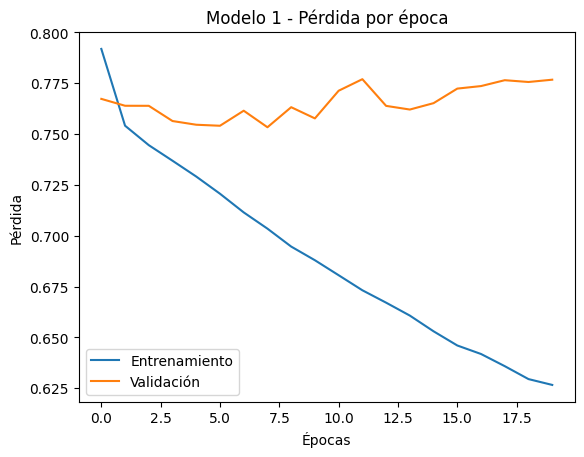

In [ ]:
with mlflow.start_run(run_name='Modelo 1'):
    model1 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(32, activation='relu'),   # Primera capa oculta
        layers.Dense(32, activation='relu'),   # Segunda capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida (3 clases)
    ])

    model1.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history1 = model1.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss1, test_acc1 = model1.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc1)

    plt.plot(history1.history['loss'], label='Entrenamiento')
    plt.plot(history1.history['val_loss'], label='Validación')
    plt.title('Modelo 1 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

## Modelo 2: con tres capas 16 neuronas en cada capa, capa de normalización y tres salidas 

2025/05/25 14:25:43 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 14:25:43 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
629/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5723 - loss: 0.8820

644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5735 - loss: 0.8801 - val_accuracy: 0.6471 - val_loss: 0.7640
Epoch 2/20
630/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6466 - loss: 0.7578

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6466 - loss: 0.7578 - val_accuracy: 0.6525 - val_loss: 0.7612
Epoch 3/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6460 - loss: 0.7539 - val_accuracy: 0.6405 - val_loss: 0.7614
Epoch 4/20
629/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6475 - loss: 0.7503

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6476 - loss: 0.7502 - val_accuracy: 0.6502 - val_loss: 0.7569
Epoch 5/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6552 - loss: 0.7379 - val_accuracy: 0.6465 - val_loss: 0.7606
Epoch 6/20
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6566 - loss: 0.7304

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6566 - loss: 0.7304 - val_accuracy: 0.6496 - val_loss: 0.7563
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6635 - loss: 0.7282 - val_accuracy: 0.6428 - val_loss: 0.7577
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6634 - loss: 0.7217 - val_accuracy: 0.6482 - val_loss: 0.7568
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6671 - loss: 0.7182 - val_accuracy: 0.6506 - val_loss: 0.7611
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6710 - loss: 0.7159 - val_accuracy: 0.6494 - val_loss: 0.7587
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6753 - loss: 0.7096 - val_accuracy: 0.6488 - val_loss: 0.7660
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6756 - loss: 0.7066 - val_accuracy: 0.6504 - val_loss: 0.7661
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6773 - loss: 0.7073 - val_accuracy: 0.6504 - 

2025/05/25 14:26:29 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 14:26:29 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 14:26:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6609 - loss: 0.7660


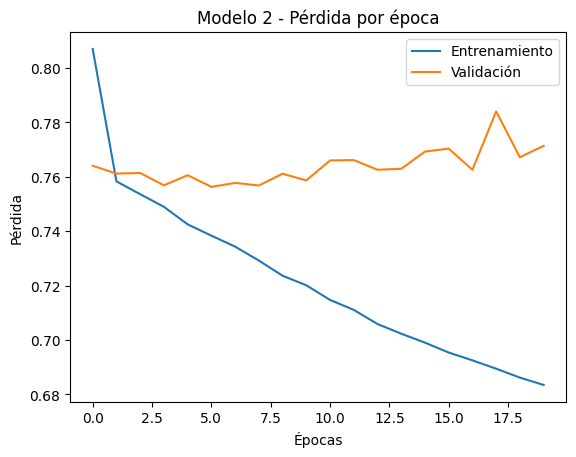

In [40]:
with mlflow.start_run(run_name='Modelo2'):
    model2 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Normalization(),               # Normalización
        layers.Dense(16, activation='relu'),   # Primera capa oculta
        layers.Dense(16, activation='relu'),   # Segunda capa oculta
        layers.Dense(16, activation='relu'),   # Tercera capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model2.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history2 = model2.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss2, test_acc2 = model2.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc2)

    plt.plot(history2.history['loss'], label='Entrenamiento')
    plt.plot(history2.history['val_loss'], label='Validación')
    plt.title('Modelo 2 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

### Modelo 3: con 4 capas ocultas y 64 neurnonas en dos capas y 32 neuronas en dos, 3 de salida 

2025/05/25 14:26:49 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 14:26:49 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6039 - loss: 0.8378

644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6044 - loss: 0.8369 - val_accuracy: 0.6498 - val_loss: 0.7592
Epoch 2/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6503 - loss: 0.7536 - val_accuracy: 0.6459 - val_loss: 0.7612
Epoch 3/20
629/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6495 - loss: 0.7448

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6497 - loss: 0.7447 - val_accuracy: 0.6531 - val_loss: 0.7532
Epoch 4/20
632/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6745 - loss: 0.7171

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6744 - loss: 0.7173 - val_accuracy: 0.6535 - val_loss: 0.7532
Epoch 5/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6726 - loss: 0.7094

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6726 - loss: 0.7094 - val_accuracy: 0.6595 - val_loss: 0.7466
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6867 - loss: 0.6858 - val_accuracy: 0.6568 - val_loss: 0.7585
Epoch 7/20
635/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6935 - loss: 0.6755

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6935 - loss: 0.6755 - val_accuracy: 0.6632 - val_loss: 0.7418
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7118 - loss: 0.6441 - val_accuracy: 0.6591 - val_loss: 0.7668
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7252 - loss: 0.6282 - val_accuracy: 0.6694 - val_loss: 0.7542
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7336 - loss: 0.6013 - val_accuracy: 0.6779 - val_loss: 0.7569
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7405 - loss: 0.5824 - val_accuracy: 0.6690 - val_loss: 0.7723
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7545 - loss: 0.5602 - val_accuracy: 0.6533 - val_loss: 0.7965
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7663 - loss: 0.5423 - val_accuracy: 0.6772 - val_loss: 0.7881
Epoch 14/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7704 - loss: 0.5261 - val_accuracy: 0.6738 -

2025/05/25 14:27:39 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 14:27:39 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 14:27:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6925 - loss: 0.8767


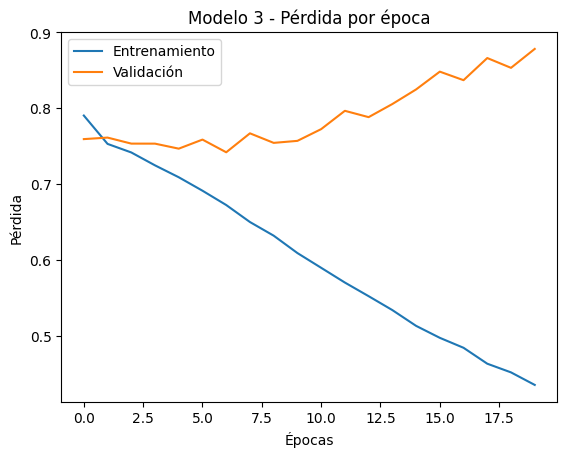

In [41]:
with mlflow.start_run(run_name='Modelo3'):
    model3 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(64, activation='relu'),  # Primera capa oculta
        layers.Dense(64, activation='relu'),   # Segunda capa oculta
        layers.Dense(32, activation='relu'),   # Tercera capa oculta
        layers.Dense(32, activation='relu'),   # Cuarta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model3.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history3 = model3.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss3, test_acc3 = model3.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc3)

    plt.plot(history3.history['loss'], label='Entrenamiento')
    plt.plot(history3.history['val_loss'], label='Validación')
    plt.title('Modelo 3 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 4: con 4 capas ocultas 32 neuronas en cada capa, 1 capa de normalización y tres  de salidad

2025/05/25 14:28:23 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 14:28:23 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
630/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6088 - loss: 0.8414

644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6093 - loss: 0.8403 - val_accuracy: 0.6434 - val_loss: 0.7653
Epoch 2/20
621/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6501 - loss: 0.7517

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6500 - loss: 0.7518 - val_accuracy: 0.6467 - val_loss: 0.7582
Epoch 3/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6506 - loss: 0.7479 - val_accuracy: 0.6321 - val_loss: 0.7628
Epoch 4/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6546 - loss: 0.7391 - val_accuracy: 0.6469 - val_loss: 0.7595
Epoch 5/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6679 - loss: 0.7218 - val_accuracy: 0.6457 - val_loss: 0.7601
Epoch 6/20
623/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6737 - loss: 0.7055

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6736 - loss: 0.7058 - val_accuracy: 0.6492 - val_loss: 0.7533
Epoch 7/20
635/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6757 - loss: 0.7040

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6757 - loss: 0.7040 - val_accuracy: 0.6539 - val_loss: 0.7513
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6816 - loss: 0.6898 - val_accuracy: 0.6554 - val_loss: 0.7591
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6894 - loss: 0.6799 - val_accuracy: 0.6556 - val_loss: 0.7541
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6945 - loss: 0.6697 - val_accuracy: 0.6628 - val_loss: 0.7575
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7045 - loss: 0.6516 - val_accuracy: 0.6473 - val_loss: 0.7682
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7007 - loss: 0.6496 - val_accuracy: 0.6597 - val_loss: 0.7599
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7153 - loss: 0.6368 - val_accuracy: 0.6608 - val_loss: 0.7625
Epoch 14/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7209 - loss: 0.6199 - val_accuracy: 0.6535 -

2025/05/25 14:29:08 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 14:29:08 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 14:29:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6630 - loss: 0.7996


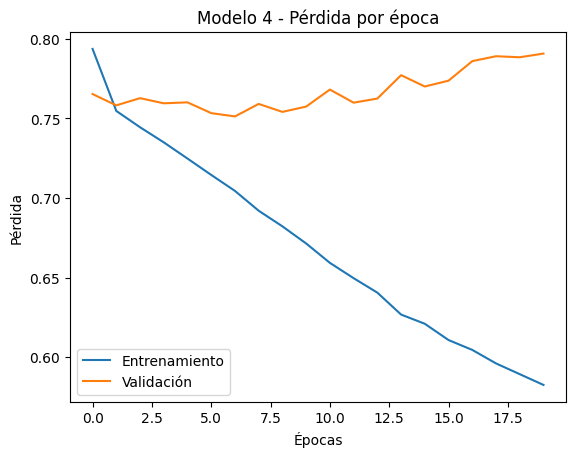

In [42]:
with mlflow.start_run(run_name='Modelo4'):
    model4 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Normalization(),               # Normalización
        layers.Dense(32, activation='relu'),  # Primera capa oculta
        layers.Dense(32, activation='relu'),  # Segunda capa oculta
        layers.Dense(32, activation='relu'),   # Tercera capa oculta
        layers.Dense(32, activation='relu'),   # Cuarta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model4.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history4 = model4.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss4, test_acc4 = model4.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc4)

    plt.plot(history4.history['loss'], label='Entrenamiento')
    plt.plot(history4.history['val_loss'], label='Validación')
    plt.title('Modelo 4 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 5: 5 capas ocultas con variando el número de neuronas de 32 a 256 en cada capa y 3 salidas 

2025/05/25 15:24:55 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 15:24:55 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6107 - loss: 0.8269

644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6108 - loss: 0.8267 - val_accuracy: 0.6408 - val_loss: 0.7656
Epoch 2/20
631/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6559 - loss: 0.7435

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6558 - loss: 0.7437 - val_accuracy: 0.6408 - val_loss: 0.7645
Epoch 3/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6587 - loss: 0.7310

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6586 - loss: 0.7311 - val_accuracy: 0.6459 - val_loss: 0.7605
Epoch 4/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6650 - loss: 0.7169 - val_accuracy: 0.6467 - val_loss: 0.7639
Epoch 5/20
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6801 - loss: 0.6872

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6801 - loss: 0.6872 - val_accuracy: 0.6570 - val_loss: 0.7467
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7034 - loss: 0.6545 - val_accuracy: 0.6463 - val_loss: 0.7734
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7249 - loss: 0.6059 - val_accuracy: 0.6659 - val_loss: 0.7486
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7402 - loss: 0.5714 - val_accuracy: 0.6764 - val_loss: 0.7518
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7709 - loss: 0.5261 - val_accuracy: 0.6805 - val_loss: 0.7820
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7882 - loss: 0.4894 - val_accuracy: 0.6857 - val_loss: 0.7937
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8125 - loss: 0.4450 - val_accuracy: 0.6991 - val_loss: 0.8238
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8293 - loss: 0.4081 - val_accuracy: 0.7160 - v

2025/05/25 15:26:13 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 15:26:13 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 15:26:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7463 - loss: 1.1431


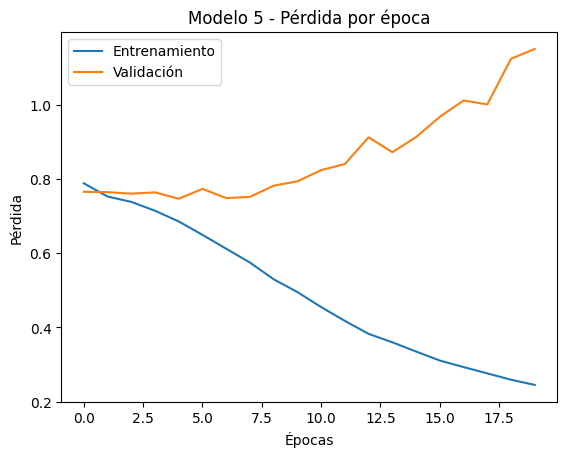

In [50]:
with mlflow.start_run(run_name='Modelo5_5'):
    model5 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(256, activation='relu'),  # Primera capa oculta
        layers.Dense(128, activation='relu'),  # Segunda capa oculta
        layers.Dense(96, activation='relu'),   # Tercera capa oculta
        layers.Dense(64, activation='relu'),   # Cuarta capa oculta
        layers.Dense(32, activation='relu'),   # Quinta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model5.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history5 = model5.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss5, test_acc5 = model5.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc5)

    plt.plot(history5.history['loss'], label='Entrenamiento')
    plt.plot(history5.history['val_loss'], label='Validación')
    plt.title('Modelo 5 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 6: 5 Capas ocultas, 128 neurnonas en la primera capa, 64 en la segunda y tercera capa, 32 neuronas en las dos últimas capas y 3 salidas 

2025/05/25 15:05:13 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 15:05:13 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
642/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6048 - loss: 0.8357

644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6049 - loss: 0.8355 - val_accuracy: 0.6389 - val_loss: 0.7703
Epoch 2/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6488 - loss: 0.7598

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6489 - loss: 0.7598 - val_accuracy: 0.6469 - val_loss: 0.7634
Epoch 3/20
632/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6639 - loss: 0.7338

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6638 - loss: 0.7339 - val_accuracy: 0.6535 - val_loss: 0.7557
Epoch 4/20
628/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6710 - loss: 0.7149

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6709 - loss: 0.7150 - val_accuracy: 0.6544 - val_loss: 0.7477
Epoch 5/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6818 - loss: 0.7045 - val_accuracy: 0.6467 - val_loss: 0.7612
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6897 - loss: 0.6702 - val_accuracy: 0.6667 - val_loss: 0.7556
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7091 - loss: 0.6482 - val_accuracy: 0.6655 - val_loss: 0.7521
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7295 - loss: 0.6112 - val_accuracy: 0.6725 - val_loss: 0.7525
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7428 - loss: 0.5816 - val_accuracy: 0.6649 - val_loss: 0.7649
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7636 - loss: 0.5465 - val_accuracy: 0.6612 - val_loss: 0.7894
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7780 - loss: 0.5228 - val_accuracy: 0.6828 - va

2025/05/25 15:06:19 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 15:06:19 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 15:06:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7095 - loss: 0.9786


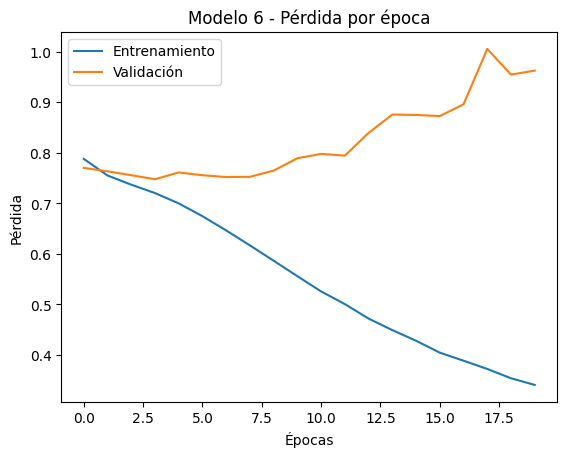

In [45]:
with mlflow.start_run(run_name='Modelo6'):
    model6 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),   # Capa de entrada
        layers.Dense(128, activation='relu'),   # Primera capa oculta (128)
        layers.Dense(64, activation='relu'),    # Segunda capa oculta (64)
        layers.Dense(64, activation='relu'),    # Tercera capa oculta (64)
        layers.Dense(32, activation='relu'),    # Cuarta capa oculta (32)
        layers.Dense(32, activation='relu'),    # Quinta capa oculta (32)
        layers.Dense(3, activation='softmax')   # Capa de salida (3 clases)
    ])

    model6.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history6 = model6.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss6, test_acc6 = model6.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc6)

    plt.plot(history6.history['loss'], label='Entrenamiento')
    plt.plot(history6.history['val_loss'], label='Validación')
    plt.title('Modelo 6 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()



### Modelo 7: 3 Capas y 256 neuronas en la primera capa, 128 neuronas en cada capa con 3 salidas 

2025/05/25 15:17:14 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 15:17:14 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
629/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6191 - loss: 0.8081

644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6195 - loss: 0.8074 - val_accuracy: 0.6506 - val_loss: 0.7655
Epoch 2/20
628/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6493 - loss: 0.7533

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6494 - loss: 0.7532 - val_accuracy: 0.6482 - val_loss: 0.7620
Epoch 3/20
634/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6618 - loss: 0.7265

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6617 - loss: 0.7265 - val_accuracy: 0.6572 - val_loss: 0.7442
Epoch 4/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6770 - loss: 0.7018

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6770 - loss: 0.7018 - val_accuracy: 0.6696 - val_loss: 0.7373
Epoch 5/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7005 - loss: 0.6616 - val_accuracy: 0.6626 - val_loss: 0.7476
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7124 - loss: 0.6266 - val_accuracy: 0.6624 - val_loss: 0.7460
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7386 - loss: 0.5782 - val_accuracy: 0.6707 - val_loss: 0.7678
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7607 - loss: 0.5374 - val_accuracy: 0.6810 - val_loss: 0.7810
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7919 - loss: 0.4822 - val_accuracy: 0.6890 - val_loss: 0.8252
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8126 - loss: 0.4411 - val_accuracy: 0.6960 - val_loss: 0.8403
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8277 - loss: 0.4037 - val_accuracy: 0.7022 - va

2025/05/25 15:18:14 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 15:18:14 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 15:18:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7299 - loss: 1.1904


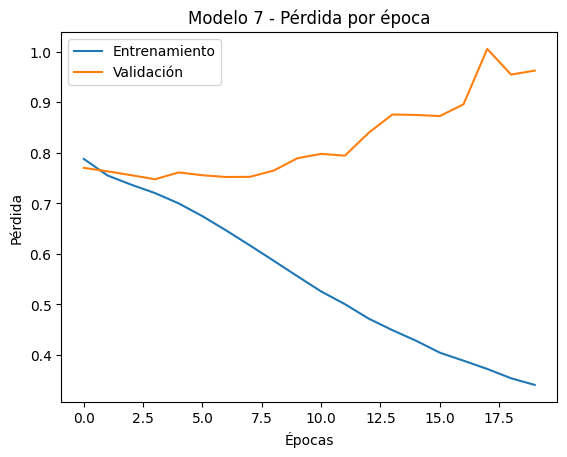

In [48]:
with mlflow.start_run(run_name='Modelo7'):
    model7 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),   # Capa de entrada
        layers.Dense(256, activation='relu'),   # Primera capa oculta (128)
        layers.Dense(128, activation='relu'),    # Segunda capa oculta (64)
        layers.Dense(128, activation='relu'),    # Tercera capa oculta (64)
        layers.Dense(3, activation='softmax')   # Capa de salida (3 clases)
    ])

    model7.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history7 = model7.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss7, test_acc7 = model7.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc7)

    plt.plot(history6.history['loss'], label='Entrenamiento')
    plt.plot(history6.history['val_loss'], label='Validación')
    plt.title('Modelo 7 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

### Comparación de modelos 

In [58]:
# Guardamos métricas manualmente (estos valores son solo ejemplos, pon los tuyos reales)
resultados_modelos = {
    'Modelo5': {'accuracy': test_acc5, 'loss': test_loss5, 'modelo': model5},
    'Modelo6': {'accuracy': test_acc6, 'loss': test_loss6, 'modelo': model6},
    'Modelo7': {'accuracy': test_acc7, 'loss': test_loss7, 'modelo': model7},
    # Agrega aquí todos los modelos que tengas
}

# Encontrar el modelo con mayor accuracy
mejor_modelo_nombre = max(resultados_modelos, key=lambda k: resultados_modelos[k]['accuracy'])
mejor_modelo = resultados_modelos[mejor_modelo_nombre]['modelo']
mejor_accuracy = resultados_modelos[mejor_modelo_nombre]['accuracy']
mejor_loss = resultados_modelos[mejor_modelo_nombre]['loss']

print(f"El mejor modelo es {mejor_modelo_nombre} con accuracy: {mejor_accuracy:.4f} y loss: {mejor_loss:.4f}")


El mejor modelo es Modelo5 con accuracy: 0.7406 y loss: 1.1356


## Mejor modelo

In [ ]:
model5.save("modelo_clasificacion.keras")